# Whakaari Dataset

This notebook builds the Whakaari case-study dataset for Cause–Trigger analysis. It combines waveform-derived hydrothermal/seismic features with weather, gas, and deformation variables on a common hourly grid.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src/whakaari"
sys.path.append(str(SRC_DIR))

from whakaari_config import (
    WHAKAARI_START,
    WHAKAARI_END,
    WHAKAARI_ERUPTION_TIME,
    TILDE_SUMMARY_URL,
    TILDE_DATA_URL,
    WHAKAARI_LAT,
    WHAKAARI_LON,
    WHAKAARI_WAVEFORM_CONFIG,
    WHAKAARI_EQ_RADIUS_KM,
    WHAKAARI_EQ_MIN_MAGNITUDE,
)

from whakaari_geonet import (
    load_so2_flux,
    load_gnss_deformation,
    load_weather_vars,
    load_local_earthquake_counts,
)

from whakaari_waveform import build_waveform_dataset

from whakaari_dataset import (
    build_master_dataframe,
    prepare_analysis_dataframe,
    scale_analysis_dataframe,
    save_whakaari_datasets,
)

from whakaari_plotting_utils import (
    WHAKAARI_ALL_COLS,
    dataset_health_report,
    plot_with_eruption_time,
    plot_variable_pdfs,
    distribution_summary,
)

from whakaari_geo_metadata import whakaari_observable_metadata
from whakaari_geo_plotting import plot_whakaari_all_variables_map

client = Client("GEONET")

## 1. GeoNet and external data + local earthquake counts

We retrieve SO₂ flux and GNSS deformation from GeoNet/Tilde, and hourly weather variables from Open-Meteo. Antecedent Precipitation Index (API) and pressure drop are derived as hydrothermal forcing proxies.

In [2]:
so2 = load_so2_flux(TILDE_DATA_URL, WHAKAARI_START, WHAKAARI_END)
gnss = load_gnss_deformation(TILDE_DATA_URL, WHAKAARI_START, WHAKAARI_END)
weather_vars = load_weather_vars(
    WHAKAARI_LAT,
    WHAKAARI_LON,
    WHAKAARI_START,
    WHAKAARI_END,
)

In [3]:
local_eq, local_eq_events = load_local_earthquake_counts(
    client=client,
    start=WHAKAARI_START,
    end=WHAKAARI_END,
    latitude=WHAKAARI_LAT,
    longitude=WHAKAARI_LON,
    radius_km=WHAKAARI_EQ_RADIUS_KM,
    min_magnitude=WHAKAARI_EQ_MIN_MAGNITUDE,
    master_freq="1h",
)

print(local_eq.shape)
display(local_eq.head())
display(local_eq.describe())

print("Event catalogue rows:", len(local_eq_events))
display(local_eq_events.head())

(1704, 1)


,local_eq_count_1h
timestamp,
2019-10-01 00:00:00+00:00,0.0
2019-10-01 01:00:00+00:00,0.0
2019-10-01 02:00:00+00:00,0.0
2019-10-01 03:00:00+00:00,0.0
2019-10-01 04:00:00+00:00,0.0


,local_eq_count_1h
count,1704.00000
mean,0.02230
std,0.15545
min,0.00000
25%,0.00000
50%,0.00000
75%,0.00000
max,2.00000


Event catalogue rows: 38


,timestamp,latitude,longitude,depth_km,magnitude
0,2019-10-03 08:31:16.157187+00:00,-37.492023,177.349884,91.318359,1.952178
1,2019-10-03 21:59:14.988377+00:00,-37.507122,177.160019,113.641197,2.438961
2,2019-10-04 15:32:48.040216+00:00,-37.538536,177.218445,4.208585,2.064422
3,2019-10-06 00:47:35.187462+00:00,-37.349205,177.316757,5.000000,2.284503
4,2019-10-06 09:21:59.040931+00:00,-37.413063,176.964996,118.466621,2.211119


## 2. Waveform feature extraction

Waveform data from WSRZ are processed into hourly seismic features: hydrothermal tremor RMS, spectral ratio, HF event rate, and a continuous tremor-response energy variable.

In [4]:
WHAKAARI_WAVEFORM_PKL = "../data/whakaari/whakaari_waveform.pkl"

waveform_df, waveform_failures = build_waveform_dataset(
    client=client,
    start=WHAKAARI_START,
    end=WHAKAARI_END,
    cfg=WHAKAARI_WAVEFORM_CONFIG,
    save_path=WHAKAARI_WAVEFORM_PKL,
    overwrite=False, # True will re-download and process waveforms, False will load from pkl
)

loaded cached waveform dataset: ..\data\whakaari\whakaari_waveform.pkl


## 3. Final hourly dataset

All variables are aligned to a common hourly timeline. Missing values are handled according to variable type, and the final dataset is saved in raw and scaled forms.

In [5]:
whakaari_raw = build_master_dataframe(
    wave=waveform_df,
    weather_vars=weather_vars,
    so2=so2,
    gnss=gnss,
    local_eq=local_eq,
    start=WHAKAARI_START,
    end=WHAKAARI_END,
    master_freq="1h",
)

whakaari_dataset = prepare_analysis_dataframe(whakaari_raw)

whakaari_dataset_scaled, whakaari_analysis_prepped, _ = scale_analysis_dataframe(whakaari_dataset)

save_whakaari_datasets(
    whakaari_raw=whakaari_raw,
    whakaari_dataset=whakaari_dataset,
    whakaari_dataset_scaled=whakaari_dataset_scaled,
    output_dir="../data/whakaari",
)

## 4. Dataset checks

We inspect missingness, summary statistics, and timestamp consistency before using the dataset for causal discovery.

In [6]:
display(dataset_health_report(whakaari_raw, "Whakaari whakaari_raw"))
display(dataset_health_report(whakaari_dataset, "Whakaari whakaari_dataset"))
display(dataset_health_report(whakaari_dataset_scaled, "Whakaari whakaari_dataset_scaled"))


Whakaari whakaari_raw
shape: (1704, 9)
duplicate timestamps: 0
time sorted: True

Missing fraction:
local_eq_count_1h         0.000000
pressure_drop             0.000587
API                       0.000587
hydro_rms_2_5             0.002347
effect_tremor_rms_5_15    0.002347
hf_event_rate_2_5         0.002347
ratio_4p5_8_over_8_16     0.002347
GNSS_deformation          0.013498
SO2_flux                  0.874413
dtype: float64


,hydro_rms_2_5,ratio_4p5_8_over_8_16,hf_event_rate_2_5,effect_tremor_rms_5_15,API,pressure_drop,SO2_flux,GNSS_deformation,local_eq_count_1h
count,1.700000e+03,1700.000000,1700.000000,1.700000e+03,1.703000e+03,1703.000000,214.000000,1681.000000,1704.00000
mean,4.682725e-06,1.641524,7.700588,5.758509e-06,9.723116e-02,-0.001174,4.376665,0.012930,0.02230
std,8.189901e-05,0.465380,7.211372,5.589572e-05,1.966607e-01,0.454432,3.769987,0.003082,0.15545
min,4.953468e-07,0.495937,0.000000,9.023086e-07,5.768107e-07,-1.800000,0.084491,0.004500,0.00000
25%,1.468631e-06,1.343118,3.000000,3.002514e-06,3.734321e-03,-0.300000,1.726030,0.010700,0.00000
50%,1.679787e-06,1.741494,6.000000,3.782496e-06,2.180734e-02,0.000000,3.215885,0.013080,0.00000
75%,2.348269e-06,1.947342,10.000000,4.570405e-06,8.111648e-02,0.300000,6.219676,0.015370,0.00000
max,2.867820e-03,2.986552,65.000000,1.963512e-03,1.195307e+00,1.800000,20.699190,0.021210,2.00000



Whakaari whakaari_dataset
shape: (1700, 9)
duplicate timestamps: 0
time sorted: True

Missing fraction:
hydro_rms_2_5             0.000000
ratio_4p5_8_over_8_16     0.000000
hf_event_rate_2_5         0.000000
effect_tremor_rms_5_15    0.000000
pressure_drop             0.000000
GNSS_deformation          0.000000
local_eq_count_1h         0.000000
API                       0.000588
SO2_flux                  0.767647
dtype: float64


,hydro_rms_2_5,ratio_4p5_8_over_8_16,hf_event_rate_2_5,effect_tremor_rms_5_15,API,pressure_drop,SO2_flux,GNSS_deformation,local_eq_count_1h
count,1.700000e+03,1700.000000,1700.000000,1.700000e+03,1.699000e+03,1700.000000,395.000000,1700.000000,1700.000000
mean,4.682725e-06,1.641524,7.700588,5.758509e-06,9.726482e-02,-0.002000,4.565517,0.012894,0.022353
std,8.189901e-05,0.465380,7.211372,5.589572e-05,1.968908e-01,0.454403,3.840615,0.003075,0.155629
min,4.953468e-07,0.495937,0.000000,9.023086e-07,5.768107e-07,-1.800000,0.084491,0.004500,0.000000
25%,1.468631e-06,1.343118,3.000000,3.002514e-06,3.696987e-03,-0.300000,1.731297,0.010660,0.000000
50%,1.679787e-06,1.741494,6.000000,3.782496e-06,2.157654e-02,-0.000000,3.446339,0.013080,0.000000
75%,2.348269e-06,1.947342,10.000000,4.570405e-06,8.049831e-02,0.300000,6.447703,0.015370,0.000000
max,2.867820e-03,2.986552,65.000000,1.963512e-03,1.195307e+00,1.800000,20.699190,0.021210,2.000000



Whakaari whakaari_dataset_scaled
shape: (1700, 18)
duplicate timestamps: 0
time sorted: True

Missing fraction:
hydro_rms_2_5                    0.000000
ratio_4p5_8_over_8_16            0.000000
hf_event_rate_2_5                0.000000
effect_tremor_rms_5_15           0.000000
pressure_drop                    0.000000
GNSS_deformation                 0.000000
hydro_rms_2_5_scaled             0.000000
local_eq_count_1h                0.000000
effect_tremor_rms_5_15_scaled    0.000000
pressure_drop_scaled             0.000000
ratio_4p5_8_over_8_16_scaled     0.000000
hf_event_rate_2_5_scaled         0.000000
local_eq_count_1h_scaled         0.000000
GNSS_deformation_scaled          0.000000
API_scaled                       0.000588
API                              0.000588
SO2_flux_scaled                  0.767647
SO2_flux                         0.767647
dtype: float64


,hydro_rms_2_5,ratio_4p5_8_over_8_16,hf_event_rate_2_5,effect_tremor_rms_5_15,API,pressure_drop,SO2_flux,GNSS_deformation,local_eq_count_1h,hydro_rms_2_5_scaled,ratio_4p5_8_over_8_16_scaled,hf_event_rate_2_5_scaled,effect_tremor_rms_5_15_scaled,API_scaled,pressure_drop_scaled,SO2_flux_scaled,GNSS_deformation_scaled,local_eq_count_1h_scaled
count,1.700000e+03,1700.000000,1700.000000,1.700000e+03,1.699000e+03,1700.000000,395.000000,1700.000000,1700.000000,1700.000000,1.700000e+03,1700.000000,1700.000000,1.699000e+03,1700.000000,3.950000e+02,1700.000000,1.700000e+03
mean,4.679368e-06,1.641524,1.863615,5.756933e-06,8.074078e-02,-0.002000,1.506928,0.012894,0.015155,6.792095,-2.499669e-01,-0.102982,1.704168,3.345699e-17,-0.004497,1.439074e-16,-0.053255,-3.343731e-17
std,8.179405e-05,0.465380,0.807251,5.584660e-05,1.451357e-01,0.454403,0.647294,0.003075,0.103950,185.210114,1.163643e+00,1.010180,48.201921,1.000000e+00,1.021636,1.000000e+00,0.882524,1.000000e+00
min,4.953467e-07,0.495937,0.000000,9.023082e-07,5.768106e-07,-1.800000,0.081111,0.004500,0.000000,-2.681980,-3.114413e+00,-2.435078,-2.485921,-5.563086e-01,-4.046945,-2.202736e+00,-2.462609,-1.457949e-01
25%,1.468630e-06,1.343118,1.386294,3.002509e-06,3.690170e-03,-0.300000,1.004777,0.010660,0.000000,-0.478129,-9.961075e-01,-0.700293,-0.673210,-5.308869e-01,-0.674491,-7.757705e-01,-0.694582,-1.457949e-01
50%,1.679785e-06,1.741494,1.945910,3.782489e-06,2.134706e-02,-0.000000,1.492081,0.013080,0.000000,0.000000,2.776642e-16,0.000000,0.000000,-4.092290e-01,-0.000000,-2.293702e-02,0.000000,-1.457949e-01
75%,2.348266e-06,1.947342,2.397895,4.570394e-06,7.742228e-02,0.300000,2.007892,0.015370,0.000000,1.513672,5.147056e-01,0.565606,0.680051,-2.286483e-02,0.674491,7.739366e-01,0.657270,-1.457949e-01
max,2.863716e-03,2.986552,4.189655,1.961587e-03,7.863220e-01,1.800000,3.077275,0.021210,1.098612,6480.643047,3.113162e+00,2.807783,1689.806665,4.861529e+00,4.046945,2.426019e+00,2.333451,1.042283e+01


## 5. Distribution diagnostics

Empirical density plots and summary statistics are used to inspect skewness, outliers, and scaling behavior. 


Whakaari analysis dataset
shape: (1700, 9)
duplicate timestamps: 0
time sorted: True

Missing fraction:
hydro_rms_2_5             0.000000
ratio_4p5_8_over_8_16     0.000000
hf_event_rate_2_5         0.000000
effect_tremor_rms_5_15    0.000000
pressure_drop             0.000000
GNSS_deformation          0.000000
local_eq_count_1h         0.000000
API                       0.000588
SO2_flux                  0.767647
dtype: float64
Whakaari analysis dataset


,count,mean,std,min,median,max,skew,n_unique,missing_fraction
API,1699.0,0.097265,0.196891,5.768107e-07,0.021577,1.195307,3.269028,1699,0.000588
GNSS_deformation,1700.0,0.012894,0.003075,4.500000e-03,0.013080,0.021210,-0.088004,71,0.000000
SO2_flux,395.0,4.565517,3.840615,8.449100e-02,3.446339,20.699190,1.577410,392,0.767647
effect_tremor_rms_5_15,1700.0,0.000006,0.000056,9.023086e-07,0.000004,0.001964,31.315037,1700,0.000000
hf_event_rate_2_5,1700.0,7.700588,7.211372,0.000000e+00,6.000000,65.000000,2.258163,45,0.000000
hydro_rms_2_5,1700.0,0.000005,0.000082,4.953468e-07,0.000002,0.002868,31.273483,1700,0.000000
local_eq_count_1h,1700.0,0.022353,0.155629,0.000000e+00,0.000000,2.000000,7.382164,3,0.000000
pressure_drop,1700.0,-0.002000,0.454403,-1.800000e+00,0.000000,1.800000,0.081552,57,0.000000
ratio_4p5_8_over_8_16,1700.0,1.641524,0.465380,4.959367e-01,1.741494,2.986552,-0.497299,1700,0.000000


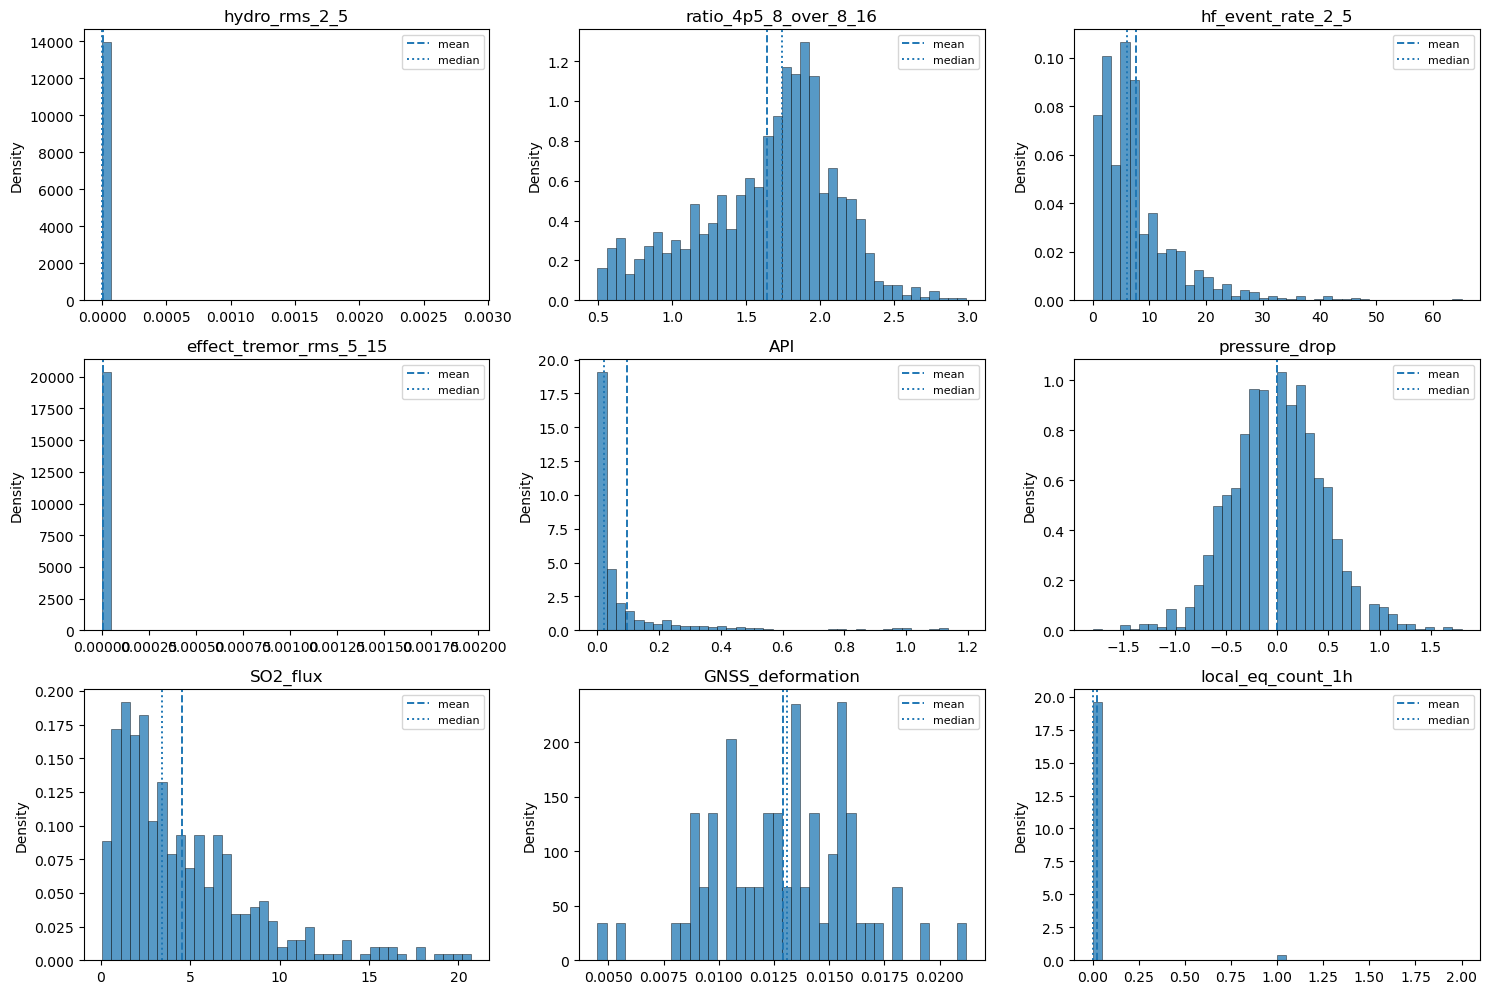

In [7]:
dataset_health_report(whakaari_dataset, "Whakaari analysis dataset")

display(distribution_summary(whakaari_dataset, "Whakaari analysis dataset"))

plot_variable_pdfs(
    whakaari_dataset,
    name="",
    cols=WHAKAARI_ALL_COLS,
    bins=40,
    filename="whakaari_pdf.png"
)

## 6. Final hourly dataset with event marker

The final variables are plotted with the eruption time marked. To assess whether the causal-analysis window and variables are physically meaningful.

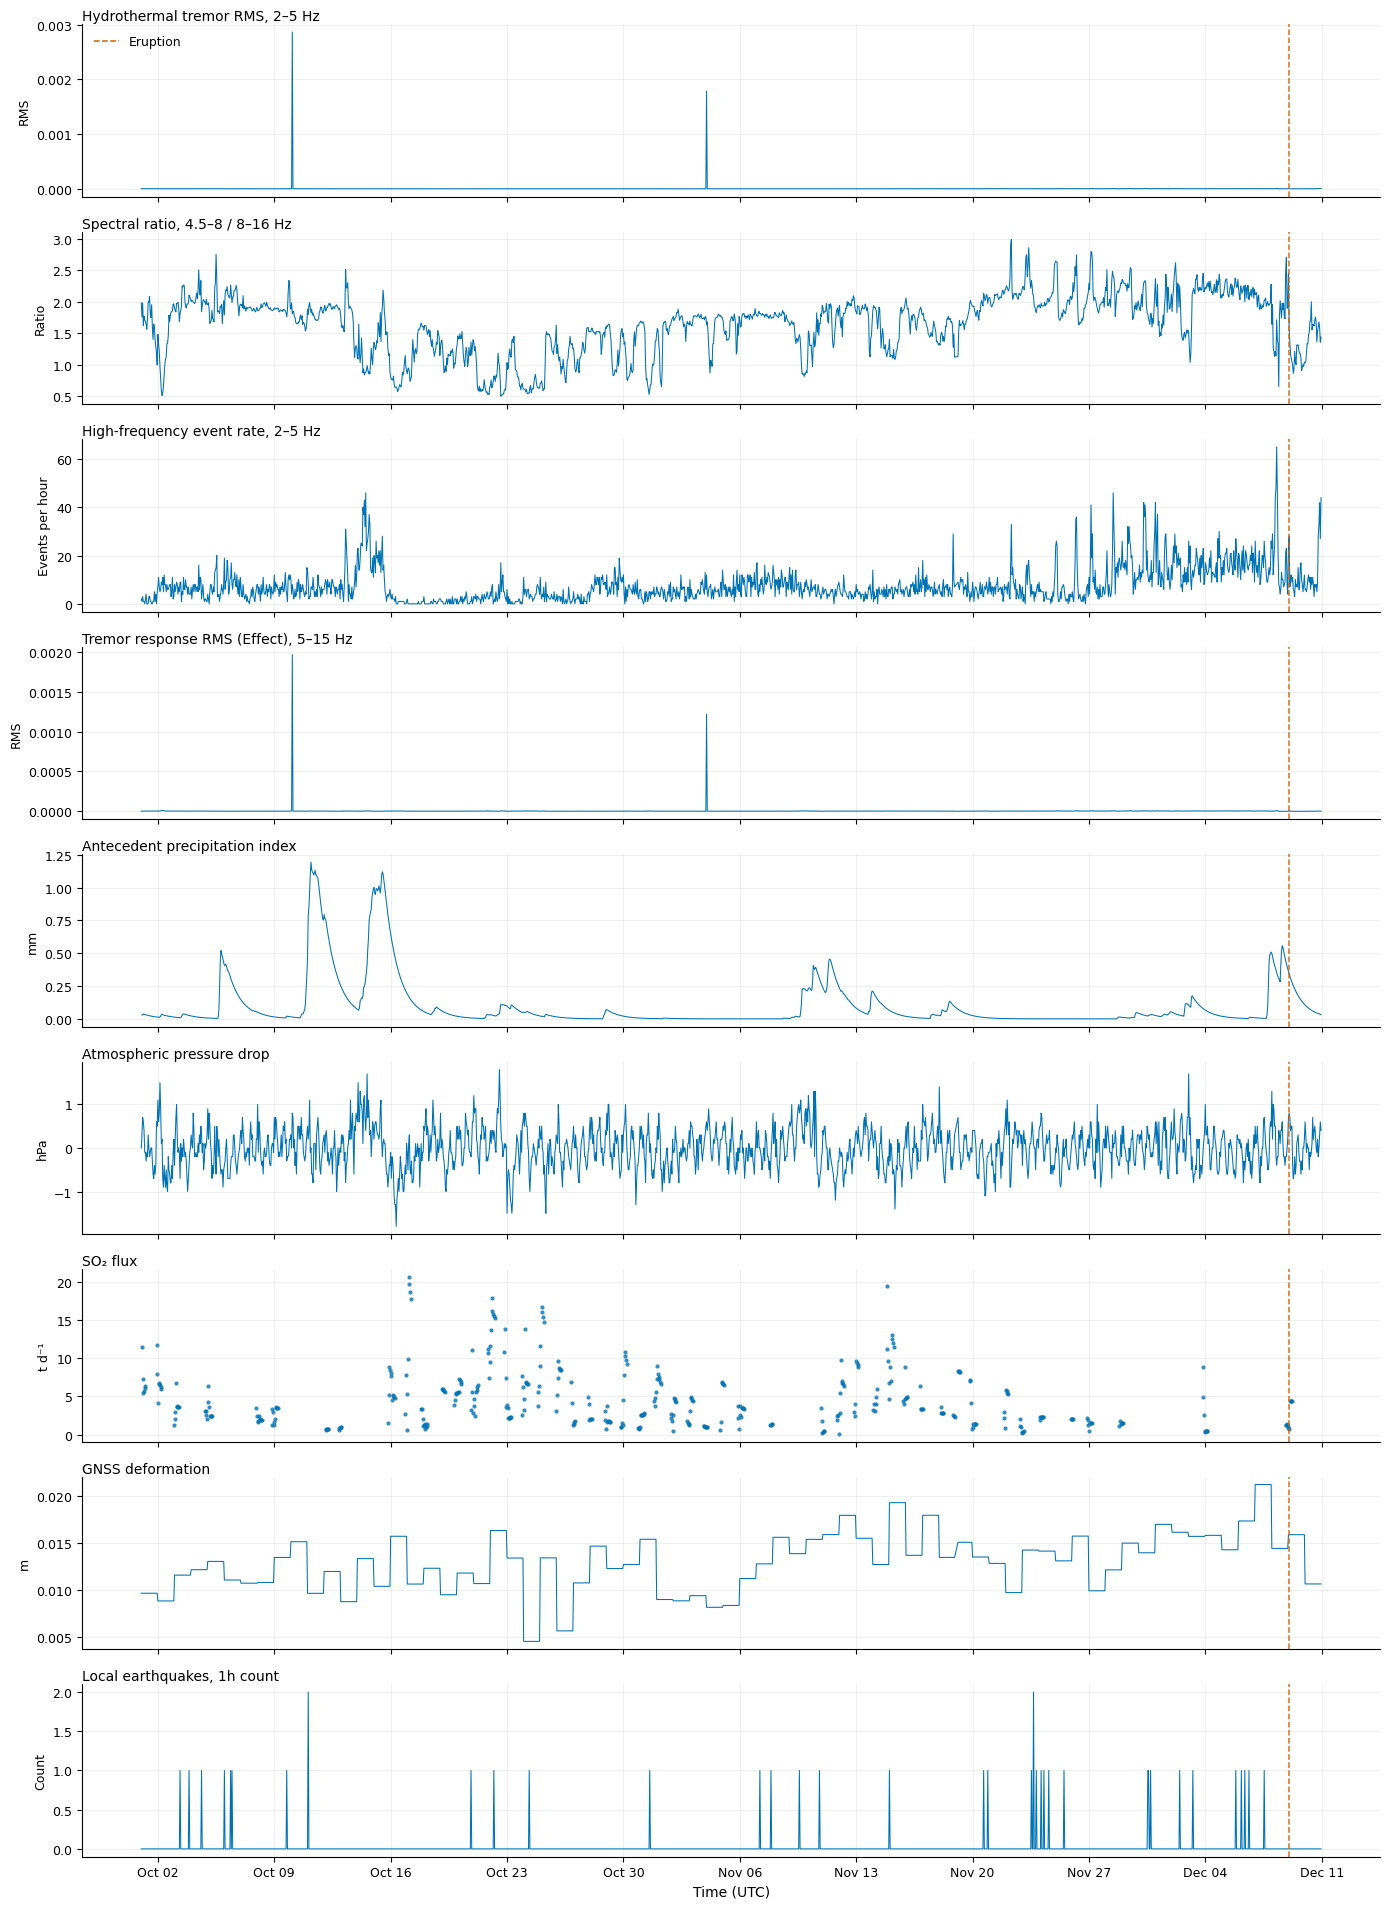

In [8]:
plot_with_eruption_time(
    "../data/whakaari/whakaari_dataset.csv",
    cols=WHAKAARI_ALL_COLS,
    eruption_time=WHAKAARI_ERUPTION_TIME,
    title="",
    tick_interval_days=7,
    filename="whakaari_variables.png",
)

## 7. Geographic Visualization

c:\Users\cescedes\Desktop\Distinguishing Causes and Triggers in Volcanic and Seismic Processes\src\whakaari\whakaari_geo_plotting.py:306: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  label_rows = pd.concat([centres, reference_df], ignore_index=True)


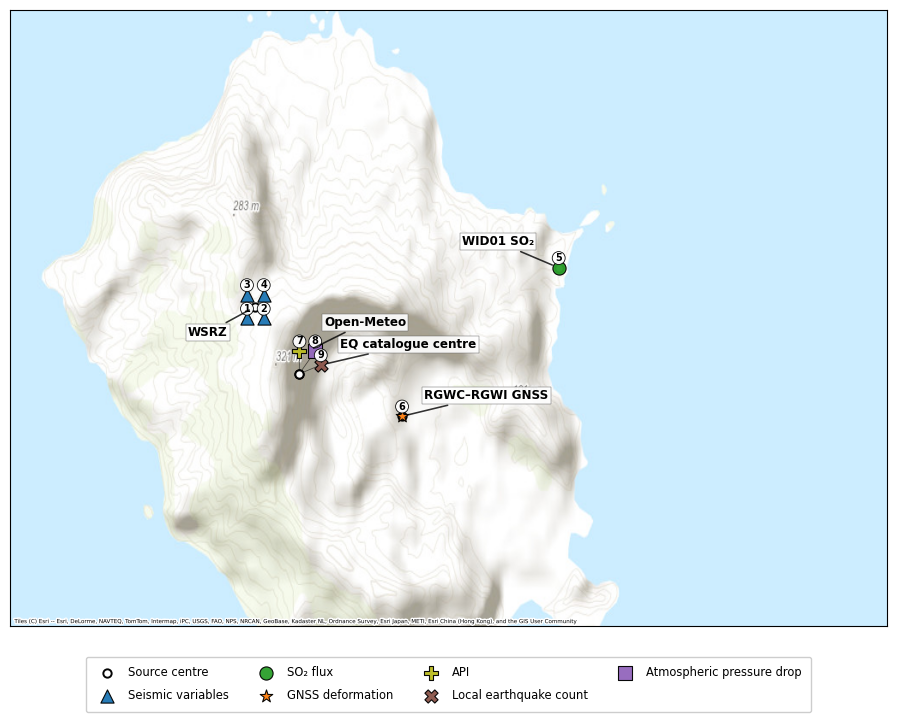

In [9]:
whakaari_meta = whakaari_observable_metadata()

fig, ax, whakaari_variable_table = plot_whakaari_all_variables_map(
    whakaari_meta,
    satellite=False,
    title=None,
    filename="whakaari_map.png",
)

c:\Users\cescedes\Desktop\Distinguishing Causes and Triggers in Volcanic and Seismic Processes\src\whakaari\whakaari_geo_plotting.py:306: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  label_rows = pd.concat([centres, reference_df], ignore_index=True)


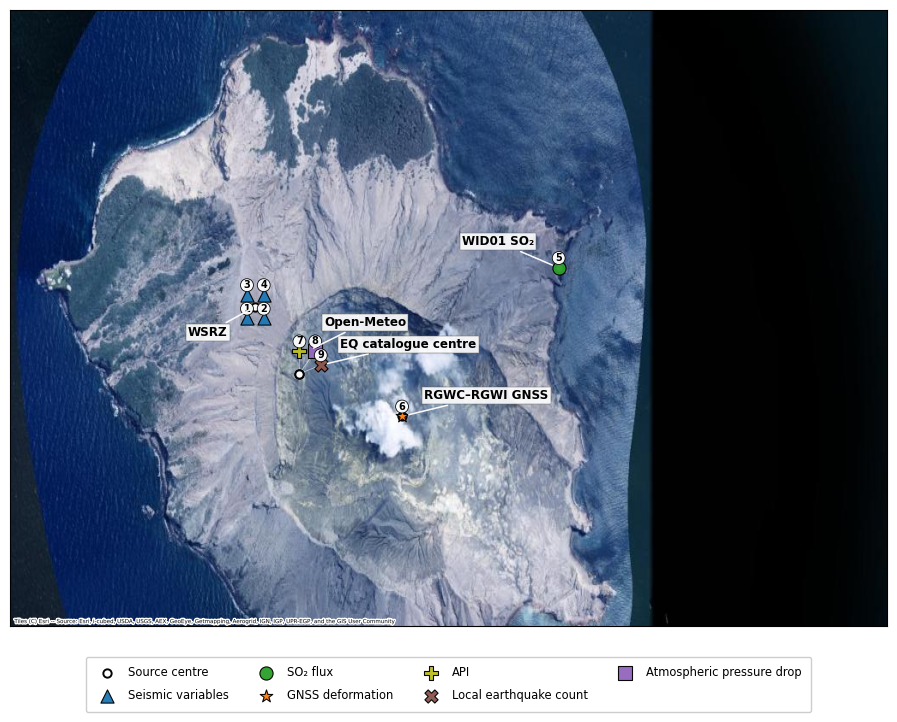

In [10]:
fig, ax, whakaari_variable_table = plot_whakaari_all_variables_map(
    whakaari_meta,
    satellite=True,
    title=None,
    filename="whakaari_satellite.png",
)